# Speech Command Recognition

Autor: Alberto Calabrese

Mail: alberto.calabrese.2@studenti.unipd.it

## Setup

In [1]:
import os
import librosa
import numpy as np
import librosa.display
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import hashlib
import tensorflow as tf
from collections import defaultdict, Counter
from keras import layers, models
import pickle
import json
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

2025-07-21 16:23:40.133747: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753115020.335959      76 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753115020.401461      76 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"GPU detected: {device_name}")
else:
    print("GPU not found. Go to Runtime > Change runtime type > GPU")

GPU detected: /device:GPU:0


I0000 00:00:1753115033.275582      76 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [3]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [4]:
BASE_PATH = "/kaggle/input/speechcommanddataset"
PROCESSED_DATA_DIR = "/kaggle/input/speechcommanddataset/processed_dataset"
OUTPUT_DATA_DIR = "/kaggle/working"

## Data Preprocessing

Do not execute the following code since it's already executed locally


In [ ]:
MAX_NUM_WAVS_PER_CLASS = 2**27 - 1  # ~134M

def which_set(filename, validation_percentage, testing_percentage):
    """
    Determines which dataset partition a file should belong to.
    This function follows the indications of the dataset creators.
    Args:
    filename: File path of the data sample.
    validation_percentage: How much of the data set to use for validation.
    testing_percentage: How much of the data set to use for testing.

    Returns:
    String, one of 'training', 'validation', or 'testing'.
    """
    base_name = os.path.basename(filename)
    hash_name = re.sub(r'_nohash_.*$', '', base_name)
    hash_name_hashed = hashlib.sha1(hash_name.encode()).hexdigest()
    percentage_hash = ((int(hash_name_hashed, 16) %
                        (MAX_NUM_WAVS_PER_CLASS + 1)) *
                        (100.0 / MAX_NUM_WAVS_PER_CLASS))
    if percentage_hash < validation_percentage:
        result = 'val'
    elif percentage_hash < (testing_percentage + validation_percentage):
        result = 'test'
    else:
        result = 'train'
    return result

In [ ]:
class SpeechPreprocessor:
    def __init__(self, dataset_path, output_path="Data/processed_dataset",
                 sample_rate=16000, n_mels=40, frame_size=0.025, frame_step=0.010,
                 noise_prob=0.3):
        """
        Initializes the SpeechPreprocessor class.

        Args:
            dataset_path (str): Path to the dataset folder.
            output_path (str): Path to the output folder.
            sample_rate (int): Sampling rate of the audio files.
            n_mels (int): Number of Mel bands to generate.
            frame_size (float): Size of the frame window in seconds.
            frame_step (float): Size of the frame step in seconds.
        """
        self.dataset_path = dataset_path
        self.output_path = output_path
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.frame_size = frame_size
        self.frame_step = frame_step
        self.noise_prob = noise_prob
        self.noise_samples = self._load_noise_samples()

        # Ensure output directories exist
        os.makedirs(self.output_path, exist_ok=True)
        for split in ["train", "val", "test"]:
            os.makedirs(f"{self.output_path}/{split}", exist_ok=True)
        print(f"Initialized SpeechPreprocessor with dataset path: {self.dataset_path} and output path: {self.output_path}")

    def _load_noise_samples(self):
        """
        Loads background noise samples from the dataset.
        Returns:
            list: List of noise samples.
        """
        noise_dir = os.path.join(self.dataset_path, "_background_noise_")
        noises = []
        for fname in os.listdir(noise_dir):
            if fname.endswith(".wav"):
                noise_path = os.path.join(noise_dir, fname)
                y, _ = librosa.load(noise_path, sr=self.sample_rate)
                noises.append(y)
        return noises

    def _time_shift(self, audio, shift_max=0.1):
        """
        Applies a random time shift to the audio signal.
        Args:
            audio (np.ndarray): Audio signal to be shifted.
            shift_max (float): Maximum shift in seconds.
        Returns:
            np.ndarray: Time-shifted audio signal.
        """
        shift = int(random.uniform(-shift_max, shift_max) * self.sample_rate)
        if shift > 0:
            audio = np.pad(audio, (shift, 0), mode='constant')[:len(audio)]
        elif shift < 0:
            audio = np.pad(audio, (0, -shift), mode='constant')[-shift:]
        return audio

    def _spec_augment(self, spectrogram, freq_mask_param=3, time_mask_param=8):
        """
        Applies SpecAugment to the spectrogram.
        Args:
            spectrogram (np.ndarray): Input spectrogram.
            freq_mask_param (int): Maximum frequency mask size.
            time_mask_param (int): Maximum time mask size.
        Returns:
            np.ndarray: Augmented spectrogram.
        """
        spec = np.copy(spectrogram)
        num_mel_channels = spec.shape[0]
        num_time_steps = spec.shape[1]

        # Frequency masking
        for _ in range(1):
            f = random.randint(0, freq_mask_param)
            f0 = random.randint(0, num_mel_channels - f)
            spec[f0:f0 + f, :] = 0

        # Time masking
        for _ in range(1):
            t = random.randint(0, time_mask_param)
            t0 = random.randint(0, num_time_steps - t)
            spec[:, t0:t0 + t] = 0

        return spec

    def _add_noise(self, audio):
        """
        Adds random background noise to the audio signal.
        Args:
            audio (np.ndarray): Audio signal to which noise will be added.
        Returns:
            np.ndarray: Audio signal with added noise.
        """
        # If no noise samples are loaded or noise probability is not met, return original audio
        if not self.noise_samples or random.random() > self.noise_prob:
            return audio

        noise = random.choice(self.noise_samples)
        if len(noise) > len(audio):
            start_idx = random.randint(0, len(noise) - len(audio))
            noise = noise[start_idx:start_idx + len(audio)]
        else:
            noise = np.pad(noise, (0, len(audio) - len(noise)))

        # Random noise level between 0.1x and 0.4x of audio signal
        noise_level = random.uniform(0.1, 0.4)
        return audio + noise_level * noise

    def _get_spectrogram(self, filepath, add_noise=False, apply_time_shift=False, apply_spec_augment=False,
                        time_shift_prob=0.5, spec_augment_prob=0.5):
        """
        Converts a .wav file into a log Mel spectrogram.

        Args:
            filepath (str): Path to the .wav file.
            add_noise (bool): Whether to add background noise to the audio.

        Returns:
            np.ndarray: Log Mel spectrogram of the audio file.
        """
        y, sr = librosa.load(filepath, sr=self.sample_rate)

        if apply_time_shift and random.random() < time_shift_prob:
            y = self._time_shift(y)

        if add_noise:
            y = self._add_noise(y)

        spectrogram = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=self.n_mels,
            hop_length=int(self.frame_step * sr),
            n_fft=int(self.frame_size * sr)
        )
        spectrogram = librosa.power_to_db(spectrogram, ref=np.max)

        if apply_spec_augment and random.random() < spec_augment_prob:
            spectrogram = self._spec_augment(spectrogram)

        # Pad or truncate to fixed width
        target_width = 101
        if spectrogram.shape[1] < target_width:
            spectrogram = np.pad(spectrogram, ((0, 0), (0, target_width - spectrogram.shape[1])), mode="constant")
        else:
            spectrogram = spectrogram[:, :target_width]

        return spectrogram


    def process_audio_files(self):
        """
        Processes all audio files and applies dataset partitioning.
        The processed spectrograms are saved in the output directory.
        The dataset partitioning is done using the official method from the dataset.
        The processed dataset will have the following structure:
        processed_dataset/
        ├── train/ # Training set
        │   ├── class1/
        │   │   ├── file1.npy
        │   │   ├── file2.npy
        │   │   └── ...
        │   ├── class2/
        │   └── ...
        ├── val/ # Validation set
        │   ├── class1/
        │   ├── class2/
        │   └── ...
        └── test/ # Testing set
            ├── class1/
            ├── class2/
            └── ...
        Data augmentation is applied only to the training set with noise addition, time shifting and spec augment.
        """
        print("Processing audio files...")

        noise_count = 0
        time_shift_count = 0
        spec_augment_count = 0

        for label in tqdm(os.listdir(self.dataset_path)):
            label_path = os.path.join(self.dataset_path, label)
            # Skip if the path is not a directory or the label is _background_noise_
            if not os.path.isdir(label_path) or label == "_background_noise_":
                continue

            for filename in os.listdir(label_path):
                if not filename.endswith(".wav"):
                    continue

                filepath = os.path.join(label_path, filename)

                # Determine dataset partition
                dataset_type = which_set(filename, 10, 10)

                # Add noise only for training set
                is_train = (dataset_type == "train")

                # Check if the spectrogram is already saved
                output_dir = os.path.join(self.output_path, dataset_type, label)
                os.makedirs(output_dir, exist_ok=True)

                output_file = os.path.join(output_dir, filename.replace(".wav", ".npy"))

                if os.path.exists(output_file):
                    continue  # Skip if the file already exists

                apply_noise = is_train and (random.random() < self.noise_prob)
                apply_time_shift = is_train and (random.random() < 0.3)
                apply_spec_augment = is_train and (random.random() < 0.3)

                # Convert to spectrogram
                spectrogram = self._get_spectrogram(
                    filepath, apply_noise, is_train, is_train,
                    time_shift_prob=0.3, spec_augment_prob=0.3
                )

                # Normalize
                spectrogram = (spectrogram - np.mean(spectrogram)) / np.std(spectrogram)

                # Save spectrogram
                np.save(output_file, spectrogram)

                # Log the augmented files
                if apply_noise:
                    noise_count += 1
                if apply_time_shift:
                    time_shift_count += 1
                if apply_spec_augment:
                    spec_augment_count += 1

        print("Data processing complete!")

        # Stats summary
        total_processed = sum(
            len([f for f in files if f.endswith(".npy")])
            for split in ["train", "val", "test"]
            for root, _, files in os.walk(os.path.join(self.output_path, split))
        )

        train_total = sum(
            len([f for f in files if f.endswith(".npy")])
            for root, _, files in os.walk(os.path.join(self.output_path, "train"))
        )

        if total_processed > 0:
            print(f"\nSummary of Preprocessing:")
            print(f"- Total samples processed: {total_processed}")

        if train_total > 0:
            print(f"- Total training samples: {train_total}")
            print(f"- Training samples with noise: {noise_count} ({(noise_count / train_total) * 100:.2f}%)")
            print(f"- Training samples with time shift: {time_shift_count} ({(time_shift_count / train_total) * 100:.2f}%)")
            print(f"- Training samples with SpecAugment: {spec_augment_count} ({(spec_augment_count / train_total) * 100:.2f}%)\n")



    def visualize_random_sample(self):
        sample_class = random.choice(os.listdir(f"{self.output_path}/train"))
        sample_file = random.choice(os.listdir(f"{self.output_path}/train/{sample_class}"))

        spectrogram = np.load(f"{self.output_path}/train/{sample_class}/{sample_file}")

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram, sr=self.sample_rate,
                                 hop_length=int(self.frame_step * self.sample_rate),
                                 x_axis="time", y_axis="mel")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram of {sample_file}")
        plt.show()

In [ ]:
def preprocess():
    # Path to the dataset
    raw_data_dir = "Data/speech_commands_v0.02"  # Raw dataset path

    # Create the preprocessor instance
    processor = SpeechPreprocessor(raw_data_dir)

    # Process all audio files
    processor.process_audio_files()

    # Visualize a sample spectrogram as a sanity check
    processor.visualize_random_sample()

preprocess()

## Models

### Data Loading

In [5]:
def get_class_weights(train_path):
    """
    Computes class weights based on the number of .wav files in each class directory.

    Args:
        train_path (str): Path to the train dataset folder.

    Returns:
        class_weights (dict): {class_index: weight}
        label_to_index (dict): {label_name: index}
        index_to_label (dict): {index: label_name}
    """
    # List class names
    class_names = sorted([
        d for d in os.listdir(train_path)
        if os.path.isdir(os.path.join(train_path, d))
    ])

    label_to_index = {label: idx for idx, label in enumerate(class_names)}
    index_to_label = {idx: label for label, idx in label_to_index.items()}

    class_counts = Counter()
    for label in class_names:
        label_dir = os.path.join(train_path, label)
        num_files = len([f for f in os.listdir(label_dir) if f.endswith(".npy")])
        class_counts[label] = num_files

    y_all = np.concatenate([[label] * class_counts[label] for label in class_names])

    weights = compute_class_weight(class_weight="balanced", classes=np.array(class_names), y=y_all)
    class_weights = {label_to_index[class_names[i]]: weights[i] for i in range(len(class_names))}

    return class_weights, label_to_index, index_to_label

train_path = PROCESSED_DATA_DIR + "/train"

class_weights, label_to_index, index_to_label = get_class_weights(train_path)

In [6]:
def load_dataset(split_path, label_to_index, input_shape=(40, 101), shuffle=True):
    data = []
    labels = []

    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue

        for fname in os.listdir(label_path):
            if not fname.endswith(".npy"):
                continue

            file_path = os.path.join(label_path, fname)
            spectrogram = np.load(file_path).astype(np.float32)

            # Ensure shape matches
            if spectrogram.shape != input_shape:
                print(f"Skipping {file_path} due to shape mismatch: {spectrogram.shape}")
                continue

            data.append(spectrogram)
            labels.append(label_to_index[label])

    data = np.array(data)[..., np.newaxis]  # Add channel dim
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices((data, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(data))

    return dataset

### Baseline CNN

In [7]:
train_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "train"), label_to_index)
val_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "val"), label_to_index, shuffle=False)
test_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "test"), label_to_index, shuffle=False)

BATCH_SIZE = 64
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1753115609.695227      76 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
def baseline_cnn(input_shape=(40, 101, 1), num_classes = len(label_to_index)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    lr = 1e-3
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss = 'sparse_categorical_crossentropy'
    metrics = ['accuracy']
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

In [9]:
model = baseline_cnn(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "baseline_cnn"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

# early_stopping_cb = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True,
#     verbose=1)

# checkpoint_cb = ModelCheckpoint(
#     filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
#     monitor='val_accuracy',
#     save_best_only=True,
#     mode='max')

# lr_scheduler_cb = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=3,
#     min_lr=1e-6,
#     verbose=1)

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=20,
#     class_weight=class_weights,
#     callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb],
#     verbose=2)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights)

Epoch 1/20


I0000 00:00:1753115749.265418     124 service.cc:148] XLA service 0x783f8800e980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753115749.266133     124 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753115749.608948     124 cuda_dnn.cc:529] Loaded cuDNN version 90300


  16/1326 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.0373 - loss: 9.2152 

I0000 00:00:1753115753.526402     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.0323 - loss: 3.7998 - val_accuracy: 0.0153 - val_loss: 3.5561
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0216 - loss: 3.5771 - val_accuracy: 0.0195 - val_loss: 3.5550
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0309 - loss: 3.5510 - val_accuracy: 0.0364 - val_loss: 3.5556
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.0311 - loss: 3.5515 - val_accuracy: 0.0357 - val_loss: 3.5552
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0280 - loss: 3.5568 - val_accuracy: 0.0357 - val_loss: 3.5551
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0266 - loss: 3.5537 - val_accuracy: 0.0180 - val_loss: 3.5558
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0213 - loss: 3.5570 - val_accuracy: 0.0353 - val_loss: 3.5551
Epoch 8/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0249 - loss: 3.55

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 99, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 99, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 55296)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,078,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,304,811 (81.27 MB)

 Trainable params: 7,101,539 (27.09 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 14,203,080 (54.18 MB)

In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0041 - loss: 3.5561  

Test accuracy: 0.0386
Test loss: 3.5554


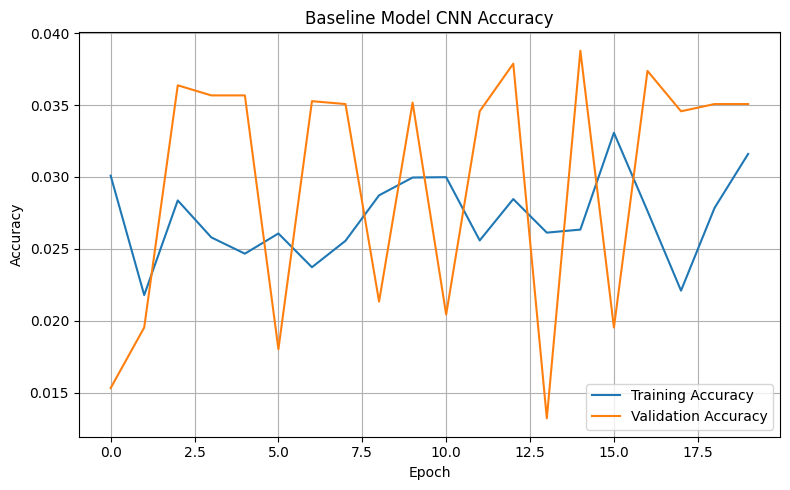

In [12]:
history_dict = history.history
plt.figure(figsize=(8, 5))
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR + "/baseline_cnn/baseline_cnn_accuracy.png")
plt.show()

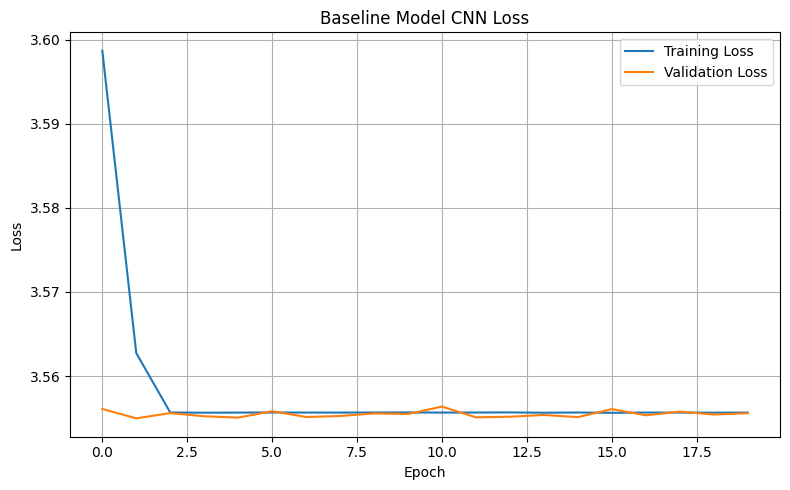

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Baseline Model CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR + "/baseline_cnn/baseline_cnn_loss.png")
plt.show()

In [14]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0039 - loss: 3.5562  

Validation accuracy: 0.0351
Validation loss: 3.5556


In [15]:
model.save(os.path.join(saving_dir, f"{model_name}_model.keras"))
model.save_weights(os.path.join(saving_dir, f"{model_name}.weights.h5"))

history_path = os.path.join(saving_dir, "training_history.pkl")
with open(history_path, "wb") as f:
    pickle.dump(history.history, f)

metadata = {
    "model_name": model_name,
    "epochs": len(history.history["accuracy"]),
    "final_train_acc": round(history.history["accuracy"][-1], 4),
    "final_val_acc": round(history.history["val_accuracy"][-1], 4),
    "input_shape": model.input_shape,
    "output_shape": model.output_shape,
    "num_params": model.count_params(),
}
metadata_path = os.path.join(saving_dir, f"metadata_{model_name}.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

### Residual CNN

In [16]:
train_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "train"), label_to_index)
val_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "val"), label_to_index, shuffle=False)
test_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "test"), label_to_index, shuffle=False)

BATCH_SIZE = 64
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [17]:
class ResidualCNN:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index)):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()

    def _res_block(self, x, filters, stride=1):
        shortcut = x

        # First convolutional layer
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Second convolutional layer
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)

        # Shortcut connection
        if stride != 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Residual blocks
        x = self._res_block(x, 32)
        x = self._res_block(x, 64, stride=2)
        x = self._res_block(x, 128, stride=2)

        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        model = models.Model(inputs, outputs)
        return model

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [18]:
residual_cnn = ResidualCNN(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "residual_cnn"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

residual_cnn.compile()
model = residual_cnn.get_model()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.3026 - loss: 2.5977 - val_accuracy: 0.6868 - val_loss: 1.1126
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.7728 - loss: 0.8393 - val_accuracy: 0.8670 - val_loss: 0.4499
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8359 - loss: 0.5851 - val_accuracy: 0.9012 - val_loss: 0.3383
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8616 - loss: 0.4910 - val_accuracy: 0.8854 - val_loss: 0.3881
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8750 - loss: 0.4353 - val_accuracy: 0.9148 - val_loss: 0.2869
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8884 - loss: 0.3830 - val_accuracy: 0.9322 - val_loss: 0.2299
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8981 - loss: 0.3485 - val_accuracy: 0.8608 - val_loss: 0.5133
Epoch 8/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.9035 -

In [19]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 40, 101,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 101,   │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 40, 101,   │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 20, 51,    │     18,496 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 20, 51,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 20, 51,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 20, 51,    │      2,112 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_6[0][0]  

 Total params: 937,259 (3.58 MB)

 Trainable params: 311,971 (1.19 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 623,944 (2.38 MB)

In [20]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9429 - loss: 0.1934

Test accuracy: 0.9390
Test loss: 0.2039


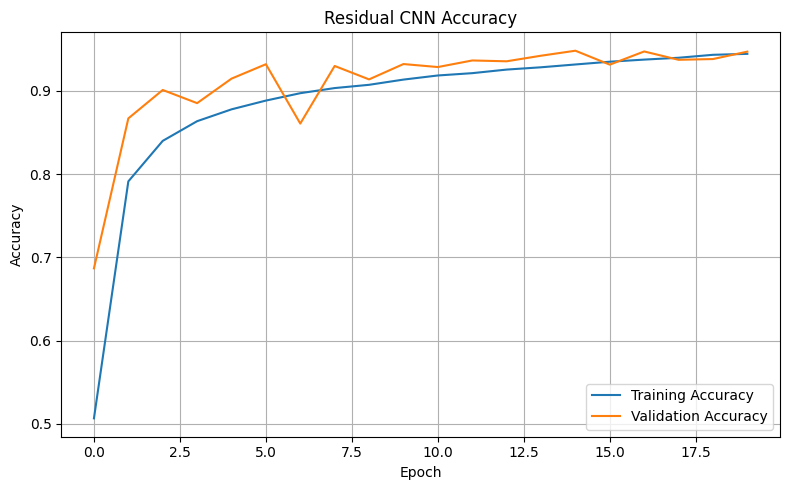

In [21]:
history_dict = history.history
plt.figure(figsize=(8, 5))
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Residual CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(saving_dir + "/residual_cnn_accuracy.png")
plt.show()

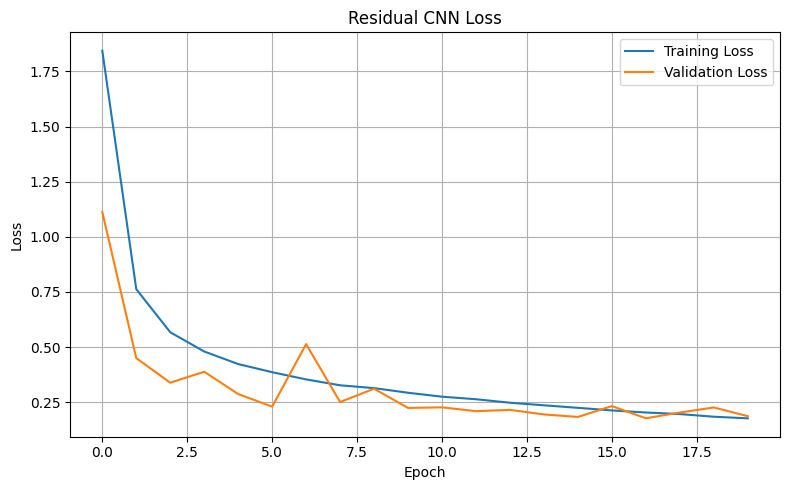

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Residual CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(saving_dir + "/residual_cnn_loss.png")
plt.show()

In [23]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9410 - loss: 0.2291

Validation accuracy: 0.9473
Validation loss: 0.1867


In [24]:
model.save(os.path.join(saving_dir, f"{model_name}_model.keras"))
model.save_weights(os.path.join(saving_dir, f"{model_name}.weights.h5"))

history_path = os.path.join(saving_dir, "training_history.pkl")
with open(history_path, "wb") as f:
    pickle.dump(history.history, f)

metadata = {
    "model_name": model_name,
    "epochs": len(history.history["accuracy"]),
    "final_train_acc": round(history.history["accuracy"][-1], 4),
    "final_val_acc": round(history.history["val_accuracy"][-1], 4),
    "input_shape": model.input_shape,
    "output_shape": model.output_shape,
    "num_params": model.count_params(),
}
metadata_path = os.path.join(saving_dir, f"metadata_{model_name}.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

### CNN + BiLSTM

In [25]:
train_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "train"), label_to_index)
val_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "val"), label_to_index, shuffle=False)
test_ds = load_dataset(os.path.join(PROCESSED_DATA_DIR, "test"), label_to_index, shuffle=False)

BATCH_SIZE = 64
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [26]:
class CNNBiLSTMModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=12,
                 lstm_units=32, dense_units=64, dropout_rate=0.3):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.lstm_units = lstm_units
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = tf.keras.Input(shape=self.input_shape)

        # CNN Layers
        x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

        # Reshape
        x = layers.Reshape((10, 800))(x)

        # Feature Compression
        x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(x)

        # BiLSTM with return_sequences
        x = layers.Bidirectional(
            layers.LSTM(self.lstm_units, return_sequences=True)
        )(x)

        # Pooling across time
        x = layers.GlobalAveragePooling1D()(x)

        # Dropout + Classifier
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.dense_units, activation='relu')(x)
        x = layers.Dropout(self.dropout_rate / 1.5)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        return models.Model(inputs, outputs)

    def compile(self, learning_rate=0.001):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    def get_model(self):
        return self.model

In [27]:
cnn_bilstm = CNNBiLSTMModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "cnn_bilstm"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

cnn_bilstm.compile()
model = cnn_bilstm.get_model()
history = model.fit(train_ds,
            validation_data=val_ds,
            epochs=20,
            class_weight=class_weights)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.0977 - loss: 3.2577 - val_accuracy: 0.4765 - val_loss: 1.8057
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.3943 - loss: 2.0313 - val_accuracy: 0.6030 - val_loss: 1.3367
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.5590 - loss: 1.4615 - val_accuracy: 0.7311 - val_loss: 0.8864
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6296 - loss: 1.2119 - val_accuracy: 0.7394 - val_loss: 0.8423
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6801 - loss: 1.0459 - val_accuracy: 0.7915 - val_loss: 0.6871
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7119 - loss: 0.9391 - val_accuracy: 0.8101 - val_loss: 0.6299
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7372 - loss: 0.8473 - val_accuracy: 0.8076 - val_loss: 0.6206
Epoch 8/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7522 -

In [28]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 40, 101, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 40, 101, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 20, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 20, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 64)         │        51,264 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,379 (1.00 MB)

 Trainable params: 87,427 (341.51 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 174,856 (683.04 KB)

In [29]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8357 - loss: 0.5498

Test accuracy: 0.8479
Test loss: 0.5246


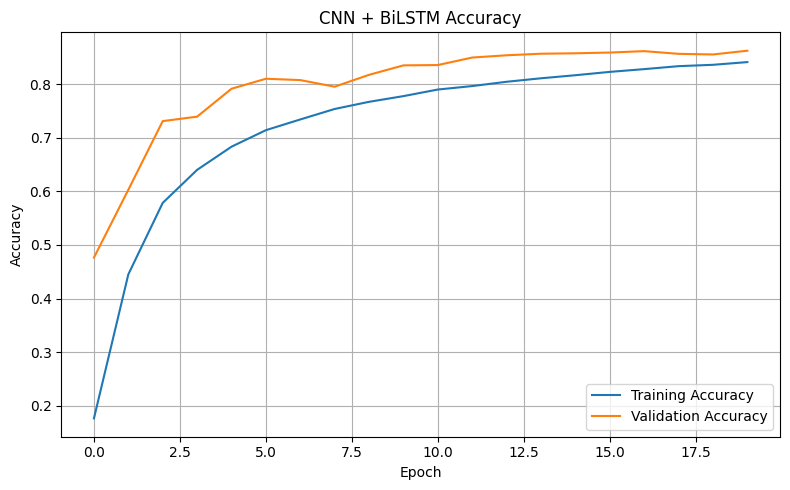

In [30]:
history_dict = history.history
plt.figure(figsize=(8, 5))
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('CNN + BiLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(saving_dir + "/cnn_bilstm_accuracy.png")
plt.show()

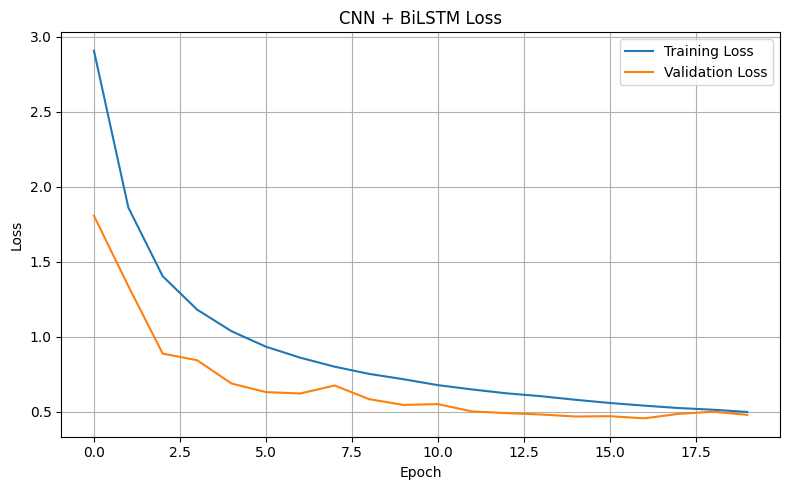

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('CNN + BiLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(saving_dir + "/cnn_bilstm_loss.png")
plt.show()

In [32]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8434 - loss: 0.5351

Validation accuracy: 0.8624
Validation loss: 0.4780


In [33]:
model.save(os.path.join(saving_dir, f"{model_name}_model.keras"))
model.save_weights(os.path.join(saving_dir, f"{model_name}.weights.h5"))

history_path = os.path.join(saving_dir, "training_history.pkl")
with open(history_path, "wb") as f:
    pickle.dump(history.history, f)

metadata = {
    "model_name": model_name,
    "epochs": len(history.history["accuracy"]),
    "final_train_acc": round(history.history["accuracy"][-1], 4),
    "final_val_acc": round(history.history["val_accuracy"][-1], 4),
    "input_shape": model.input_shape,
    "output_shape": model.output_shape,
    "num_params": model.count_params(),
}
metadata_path = os.path.join(saving_dir, f"metadata_{model_name}.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

### Transformer-Based

- Implement a **Speech-Transformer** based on the paper
    - Initial convolution layers + positional encoding + attention-based encoder-decoder
    - Optional: 2D-Attention across time and frequency dimensions
    - Find something to differentiate it from the one of the paper !
    
    [**CNN + Light Transformer Encoder Block**](https://www.notion.so/CNN-Light-Transformer-Encoder-Block-1d186f0970468004abe2e31d061adc0b?pvs=21)
    
    [Other solution:](https://www.notion.so/Other-solution-1d186f09704680a5bbd4d57b877d2b0d?pvs=21)

### GAN

CNN or Transformer as feature extractor + a GAN-style discriminator as classifier (more experimental but I think it could be interesting!)


## Models Evaluation

In [ ]:
class ModelEvaluator:
    def __init__(self, models_path, label_map_path, processed_dataset_path, batch_size=32, output_dir="output"):
        self.models_path = models_path
        self.label_map_path = label_map_path
        self.processed_dataset_path = processed_dataset_path
        self.batch_size = batch_size
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        self.models_info = []

    def load_test_data(self):
        # Load .npy test data
        test_ds, X_test, y_test = self._load_dataset(
            split_path=os.path.join(self.processed_dataset_path, "test"),
            label_to_index=label_to_index,
            shuffle=False
        )

        self.test_ds = test_ds
        self.X_test = X_test
        self.y_test = y_test

    def _load_dataset(self, split_path, label_to_index, input_shape=(40, 101), shuffle=False):
        data, labels = [], []

        for label in os.listdir(split_path):
            label_path = os.path.join(split_path, label)
            if not os.path.isdir(label_path):
                continue

            for fname in os.listdir(label_path):
                if not fname.endswith(".npy"):
                    continue

                file_path = os.path.join(label_path, fname)
                spectrogram = np.load(file_path).astype(np.float32)

                if spectrogram.shape != input_shape:
                    print(f"Skipping {file_path}, wrong shape: {spectrogram.shape}")
                    continue

                data.append(spectrogram)
                labels.append(label_to_index[label])

        data = np.array(data)[..., np.newaxis]
        labels = np.array(labels)

        dataset = tf.data.Dataset.from_tensor_slices((data, labels))
        if shuffle:
            dataset = dataset.shuffle(buffer_size=len(data))
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)

        return dataset, data, labels

    def evaluate_all(self):
        self.load_test_data()

        model_folders = [
            d for d in os.listdir(self.models_path)
            if os.path.isdir(os.path.join(self.models_path, d)) and not d.startswith("__")
        ]

        for model_name in model_folders:
            print(f"\nEvaluating {model_name}...")
            folder_path = os.path.join(self.models_path, model_name)

            model_path = os.path.join(folder_path, f"{model_name}_model.keras")
            metadata_path = os.path.join(folder_path, f"metadata_{model_name}.json")

            if not os.path.exists(model_path) or not os.path.exists(metadata_path):
                print(f"Skipping {model_name}: Missing model or metadata.")
                continue

            model = load_model(model_path)
            y_pred = np.argmax(model.predict(self.test_ds, verbose=0), axis=1)

            acc = accuracy_score(self.y_test, y_pred)
            precision = precision_score(self.y_test, y_pred, average="macro")
            recall = recall_score(self.y_test, y_pred, average="macro")
            f1_macro = f1_score(self.y_test, y_pred, average="macro")
            f1_weighted = f1_score(self.y_test, y_pred, average="weighted")

            with open(metadata_path, "r") as f:
                metadata = json.load(f)

            # Get model size in MB
            model_size_bytes = os.path.getsize(model_path)
            model_size_mb = round(model_size_bytes / (1024 * 1024), 2)

            # Update metadata with evaluation metrics
            metadata.update({
                "accuracy": acc,
                "precision": precision,
                "recall": recall,
                "f1_macro": f1_macro,
                "f1_weighted": f1_weighted,
                "model_size_MB": model_size_mb,
            })

            self.models_info.append(metadata)
            self.plot_confusion_matrix(self.y_test, y_pred, model_name)

    def plot_confusion_matrix(self, y_true, y_pred, model_name):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()

        model_output_dir = os.path.join(self.output_dir, model_name)
        os.makedirs(model_output_dir, exist_ok=True)

        save_path = os.path.join(model_output_dir, f"confusion_matrix_{model_name}.png")
        plt.savefig(save_path)
        plt.close()
        print(f"Confusion matrix saved to: {save_path}")

    def export_results_csv(self, filename="evaluation_results.csv"):
        df = pd.DataFrame(self.models_info)
        output_path = os.path.join(self.output_dir, filename)
        df.to_csv(output_path, index=False)
        print(f"\nEvaluation results saved to: {output_path}")
        return df

In [ ]:
def evaluate_model():
    # Path to the models
    models_path = "models" # To be fixed

    # Create the evaluator instance
    evaluator = ModelEvaluator(
        models_path=models_path,
        label_map_path="label_to_index.pkl",
        processed_dataset_path="Data/processed_dataset",
        batch_size=32,
        output_dir="output"
    )

    # Evaluate all models
    evaluator.evaluate_all()

    # Export results to CSV
    df = evaluator.export_results_csv()
    print(df)

In [ ]:
evaluate_model()

## Optimization for Edge Devices